In [1]:
import matplotlib.pyplot as plt
from glob import glob
import matplotlib.patches as mpatches
# import cosima_cookbook as cc
import numpy as np
from matplotlib.gridspec import GridSpec
import matplotlib.ticker as mticker
import cmocean.cm as cm
import xarray as xr
import cartopy
import cartopy.crs as ccrs
import cartopy.feature as cft
import gc
from scipy.interpolate import griddata
from matplotlib import ticker
import scipy.io as sio
# import seawater as sw
import seaborn as sns
import matplotlib.patheffects as pe
from scipy import stats
import matplotlib.patheffects as mpe
from tqdm import tqdm

In [2]:
def argnear(dat,val,how_many=1):
    dif = np.abs(dat-val)
    idx = np.argsort(dif)
    return idx[:how_many]

In [3]:
# Set figures properties
# sns.set_style('whitegrid')
# sns.reset_orig()
plt.rcParams['font.size'] = 12
plt.rcParams['font.weight'] = 'bold'
plt.rcParams['xtick.labelsize'] = 12
plt.rcParams['ytick.labelsize'] = 12
plt.rcParams['axes.labelweight'] = 'bold'
plt.rcParams['axes.titleweight'] = 'bold'

## SST trend

In [4]:
path_load = '/g/data/v45/fs3401/AmelieMeyer_Agulhas_meander/scripts/trends/output/'
ds = xr.open_dataset(path_load + 'SLA_trend_26years.nc')

SST_data  = xr.open_dataset(path_load+'SST_trend_26years.nc')
SST_trend = SST_data.slope_decade_SST.load()
SST_lon, SST_lat = SST_data.longitude, SST_data.latitude

## Frontal position

In [5]:
path = '/g/data/v45/fs3401/AmelieMeyer_Agulhas_meander/data/'
data_meander   = glob(path + 'altimetry_meander_location_daily_1993_2019_3m_30thrs.mat')

meander_var = sio.loadmat(data_meander[0])
lon_front  = meander_var['meand_lon'][:,0]
lat_front = meander_var['meand_loc_lat'].T
###################################################################
front_boundary = argnear(lon_front, 65)[0]
lon_front      = lon_front[:front_boundary]
lat_front      = lat_front[:,:front_boundary]
lat_front_mean = np.nanmean(lat_front, axis = 0)


/jobfs/173906483.gadi-pbs/ipykernel_3844495/3459868093.py:11: RuntimeWarning: Mean of empty slice
  lat_front_mean = np.nanmean(lat_front, axis = 0)


## Precipitation, Evaporation, SHF, LHF

In [6]:
path_load = '/g/data/v45/fs3401/AmelieMeyer_Agulhas_meander/scripts/trends/output/'
ds        = xr.open_dataset(path_load+'ppt_evap_shf_lhf_trends_26years.nc')
lon, lat  = ds.longitude, ds.latitude
#####################################################################################
slope_decade_precipitation = ds.slope_decade_precipitation
slope_decade_evaporation   = ds.slope_decade_evaporation
slope_decade_slhf          = ds.slope_decade_slhf
slope_decade_sshf          = ds.slope_decade_sshf
#####################################################################################
p_value_precipitation = ds.p_value_precipitation
p_value_evaporation   = ds.p_value_evaporation
p_value_slhf           = ds.p_value_slhf
p_value_sshf          = ds.p_value_sshf

## Ta and wind speed trends

In [7]:
ds        = xr.open_dataset(path_load+'Ta_trend_26years.nc')
slope_decade_Ta, p_value_Ta = ds.slope_decade_Ta, ds.p_value_Ta

ds        = xr.open_dataset(path_load+'wind_trend_26years.nc')
slope_decade_wind, p_value_wind = ds.slope_decade_wind, ds.p_value_wind

## Wind stress curl and isentropic surfaces trend

In [8]:
path_load = '/g/data/jk72/fs3401/Desktop/Agulhas_meander/output/'

ds        = xr.open_dataset(path_load+'wsc_trend_26years.nc')
slope_decade_wsc, p_value_wsc = ds.slope_decade_wsc, ds.p_value_wsc

ds = xr.open_dataset(path_load+'ea.ans.trend.1993to2019.nearsfc.slope.nc')
slope_decade_sis, p_value_sis = ds.slope_trend, ds.slope_trend_pvalue

## Posisitons to extract the trends

In [9]:
lat_crest_1, lon_crest_1   = -40.5, 25.3
lat_crest_2, lon_crest_2   = -40.4, 31
lat_crest_4, lon_crest_4   = -41.5, 52.3
lat_crest_7, lon_crest_7   = -44.3, 62.3
############### TROUGHS
lat_trough_1, lon_trough_1 = -38.2, 27.8
lat_trough_2, lon_trough_2 = -37.7, 32.3
lat_trough_3, lon_trough_3 = -39.5, 38
lat_trough_4, lon_trough_4 = -39.5, 50

## Figures

In [10]:
path_fig = '/g/data/jk72/fs3401/Desktop/Agulhas_meander/figures/'
import matplotlib.dates as mdates


## Second version

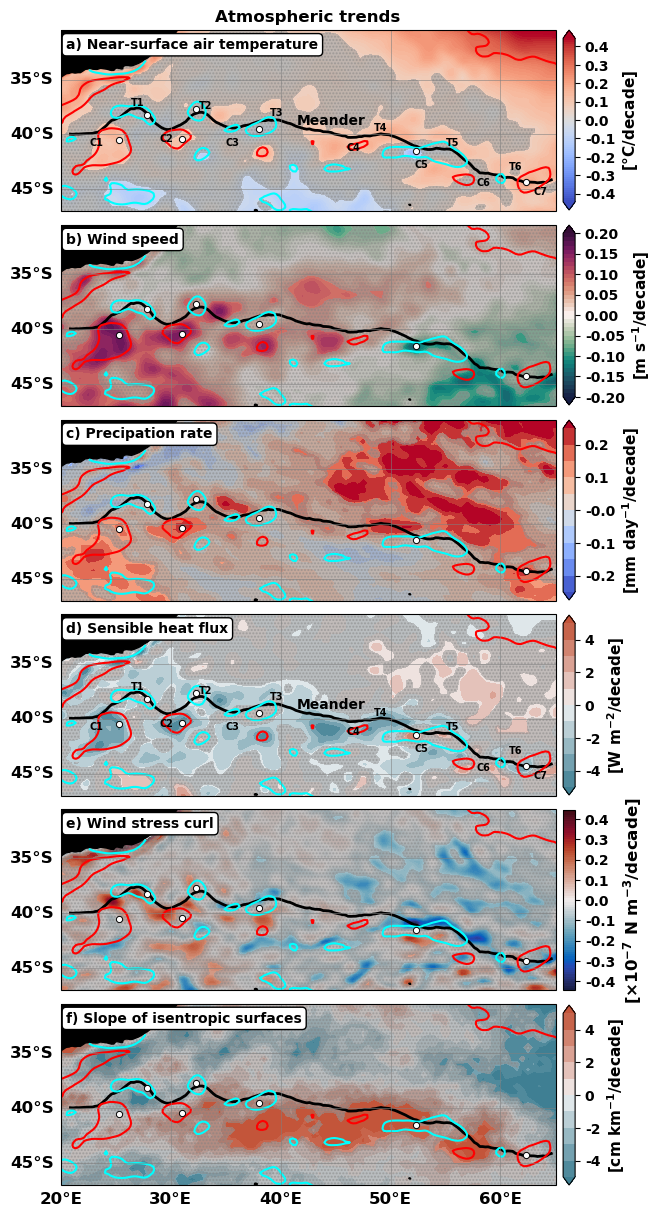

In [11]:
fig = plt.figure(figsize = (12,15))
grd = GridSpec(101,100)
extent = [19.99, 65.01, -47, -30.5]
props = dict(boxstyle='round', facecolor='w', alpha=1)
outline = mpe.withStroke(linewidth=2, foreground='w')

####################### FIGURE 
ax = [fig.add_subplot(grd[:16,:], projection=ccrs.PlateCarree()),
      fig.add_subplot(grd[17:33,:], projection=ccrs.PlateCarree()),
      fig.add_subplot(grd[34:50,:], projection=ccrs.PlateCarree()),
      fig.add_subplot(grd[51:67,:], projection=ccrs.PlateCarree()),
      fig.add_subplot(grd[68:84,:], projection=ccrs.PlateCarree()),
      fig.add_subplot(grd[85:101,:], projection=ccrs.PlateCarree())]

htch = ['.....']
####################### FIGURE 1
cf1 = ax[0].contourf(lon, lat, slope_decade_Ta, np.arange(-.4,.41,.01), cmap = 'coolwarm', extend='both')
hatch1 = ax[0].contourf(lon, lat, p_value_Ta, [0.05,1], cmap='Greys', hatches=htch, alpha=.5) 
####################### FIGURE 2
cf2 = ax[1].contourf(lon, lat, slope_decade_wind, np.arange(-.2,.21,.01), cmap = cm.curl, extend='both')
hatch2 = ax[1].contourf(lon, lat, p_value_wind, [0.05,1], cmap='Greys',alpha=.5, hatches=htch) 
####################### FIGURE 3
cf3 = ax[2].contourf(lon, lat, slope_decade_precipitation, np.arange(-.25,.3,.05), cmap = 'coolwarm', extend='both')
hatch3 = ax[2].contourf(lon, lat, p_value_precipitation, [0.05,1], cmap='Greys',alpha=.5, hatches=htch) 
####################### FIGURE 4
cf4 = ax[3].contourf(lon, lat, slope_decade_sshf, np.arange(-5,6,1), cmap = sns.diverging_palette(220, 20, as_cmap=True), extend='both')
hatch4 = ax[3].contourf(lon, lat, p_value_sshf, [0.05,1], cmap='Greys',alpha=.5, hatches=htch) 
####################### FIGURE 5
cf5 = ax[4].contourf(lon, lat, slope_decade_wsc*1e7, levels= np.arange(-.40,.41,.01), cmap=cm.balance)
hatch5 = ax[4].contourf(lon, lat, p_value_wsc, [0.05,1], cmap='Greys',alpha=.5, hatches=htch) 
####################### FIGURE 6
cf6 = ax[5].contourf(slope_decade_sis.longitude, slope_decade_sis.latitude, slope_decade_sis*1e5, np.arange(-5,6,1), cmap = sns.diverging_palette(220, 20, as_cmap=True), extend='both')
hatch6 = ax[5].contourf(slope_decade_sis.longitude, slope_decade_sis.latitude, p_value_sis, [0.05,1], cmap='Greys',alpha=.5, hatches=htch) 

cf, cbar_ = [cf1, cf2, cf3, cf4, cf5, cf6], []
cf_hatch  = [hatch1, hatch2, hatch3, hatch4, hatch5, hatch6]
txt = ['a) Near-surface air temperature', 'b) Wind speed', 'c) Precipation rate', 'd) Sensible heat flux', 'e) Wind stress curl', 'f) Slope of isentropic surfaces']
for i in range(len(ax)):
    line = ax[i].plot(lon_front, lat_front_mean, color = 'k', linewidth = 2)
    cr_SST = ax[i].contour(SST_lon, SST_lat, SST_trend, [-.1,.3], colors = ['cyan', 'red'], linestyles = 'solid')
    handles_SST, labels_SST = cr_SST.legend_elements()
    ax[i].annotate(text=txt[i], color='k', xy=(20.5,-32.2), xycoords='data', bbox=props, fontsize = 10, zorder = 300)  

    cf_hatch[i].set_edgecolor('grey')
    cf_hatch[i].set_linewidth(0)   
    ### Some annotation
    ft = 7
    if i == 0 or i == 3:
        ax[i].annotate(text='Meander', color='k', xy=(41.5,-39.1), xycoords='data', fontsize = 10, zorder = 300, fontweight = 'bold')
        ax[i].annotate(text='C1', color='k', xy=(22.6,-41), xycoords='data', fontsize = ft, zorder = 300)
        ax[i].annotate(text='T1', color='k', xy=(26.4,-37.35), xycoords='data', fontsize = ft, zorder = 300)
        ax[i].annotate(text='C2', color='k', xy=(29,-40.7), xycoords='data', fontsize = ft, zorder = 300)
        ax[i].annotate(text='T2', color='k', xy=(32.6,-37.7), xycoords='data', fontsize = ft, zorder = 300)
        ax[i].annotate(text='C3', color='k', xy=(35,-41), xycoords='data', fontsize = ft, zorder = 300)
        ax[i].annotate(text='T3', color='k', xy=(39,-38.3), xycoords='data', fontsize = ft, zorder = 300)
        ax[i].annotate(text='C4', color='k', xy=(46,-41.5), xycoords='data', fontsize = ft, zorder = 300)
        ax[i].annotate(text='T4', color='k', xy=(48.5,-39.7), xycoords='data', fontsize = ft, zorder = 300)
        ax[i].annotate(text='C5', color='k', xy=(52.2,-43), xycoords='data', fontsize = ft, zorder = 300)
        ax[i].annotate(text='T5', color='k', xy=(55,-41), xycoords='data', fontsize = ft, zorder = 300)
        ax[i].annotate(text='C6', color='k', xy=(57.8,-44.7), xycoords='data', fontsize = ft, zorder = 300)
        ax[i].annotate(text='T6', color='k', xy=(60.8,-43.2), xycoords='data', fontsize = ft, zorder = 300)
        ax[i].annotate(text='C7', color='k', xy=(63,-45.5), xycoords='data', fontsize = ft, zorder = 300)
    
    ## Scatter
    ax[i].scatter(lon_crest_1, lat_crest_1, s = 20, color = 'w', edgecolor = 'k', zorder = 50, linewidth=.7)
    ax[i].scatter(lon_crest_2, lat_crest_2, s = 20, color = 'w', edgecolor = 'k', zorder = 50, linewidth=.7)
    ax[i].scatter(lon_crest_4, lat_crest_4, s = 20, color = 'w', edgecolor = 'k', zorder = 50, linewidth=.7)
    ax[i].scatter(lon_crest_7, lat_crest_7, s = 20, color = 'w', edgecolor = 'k', zorder = 50, linewidth=.7)
    ax[i].scatter(lon_trough_1, lat_trough_1, s = 20, color = 'w', edgecolor = 'k', zorder = 50, linewidth=.7)
    ax[i].scatter(lon_trough_2, lat_trough_2, s = 20, color = 'w', edgecolor = 'k', zorder = 50, linewidth=.7)
    ax[i].scatter(lon_trough_3, lat_trough_3, s = 20, color = 'w', edgecolor = 'k', zorder = 50, linewidth=.7)
    # ax[i].scatter(lon_trough_4, lat_trough_4, s = 20, color = 'w', edgecolor = 'k', zorder = 50, linewidth=.7)
    
    ## Grid
    ax[i].set_extent(extent, ccrs.PlateCarree())
    ax[i].add_feature(cartopy.feature.COASTLINE)
    ax[i].add_feature(cartopy.feature.LAND, facecolor='k', zorder=10)
    gl = ax[i].gridlines(draw_labels = False, crs=ccrs.PlateCarree(), linewidth=0.4, color='grey')
    gl.left_labels = True
    gl.ylabel_style = {'size': 12}
    gl.ylocator = mticker.FixedLocator(np.arange(-60, -30, 5))
    gl.xlocator = mticker.FixedLocator(np.arange(10, 80, 10))

    # Colorbar
    # bar = plt.axes([0.8, 0.698-i*.17-i*.023, 0.01, 0.18])
    bar = plt.axes([0.725, 0.76-i*.12-i*.01, 0.01, 0.12])
    cbar = plt.colorbar(cf[i], cax = bar)  
    cbar.ax.tick_params(labelsize=10) 
    cbar_.append(cbar)
    if i == 0:
        # gl.top_labels = True
        cbar.ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.1f'))
        cbar_[i].set_label(r'[$\degree$C/decade]', fontsize = 11)
    if i == 1:
        cbar.ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.2f'))
        cbar_[i].set_label(r'[m s$^{-1}$/decade]', fontsize = 11)
    if i == 2:
        cbar.ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.1f'))
        # cbar_[i].set_label(r'[kg m$^{-2}$ day$^{-1}$/decade]', fontsize = 11)
        cbar_[i].set_label(r'[mm day$^{-1}$/decade]', fontsize = 11)
    if i == 3: 
        cbar.ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.0f'))
        cbar_[i].set_label(r'[W m$^{-2}$/decade]', fontsize = 11)
    if i == 4:
        cbar.ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.1f'))
        cbar_[i].set_label(r'[$\times10^{-7}$ N m$^{-3}$/decade]') 
    if i == 5:
        cbar.ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.0f'))
        cbar_[i].set_label(r'[cm km$^{-1}$/decade]', fontsize = 11)
gl.bottom_labels = True
ax[0].set_title('Atmospheric trends', fontsize = 12)

# ax[0].legend(handles_SST, 
#              [r'SST trend: -0.1$\degree$C decade$^{-1}$', 'SST trend: +0.3$\degree$C decade$^{-1}$'],
#              loc = 'upper right', fontsize = 7, facecolor = 'lightgrey', shadow=True)

plt.savefig(path_fig + 'Fig3.jpg', dpi =300, bbox_inches = 'tight')

## First version

  cf_hatch[i].collections[0].set_edgecolor('grey')

  cf_hatch[i].collections[0].set_linewidth(0)

  cf_hatch[i].collections[0].set_edgecolor('grey')

  cf_hatch[i].collections[0].set_linewidth(0)

  cf_hatch[i].collections[0].set_edgecolor('grey')

  cf_hatch[i].collections[0].set_linewidth(0)

  cf_hatch[i].collections[0].set_edgecolor('grey')

  cf_hatch[i].collections[0].set_linewidth(0)

  cf_hatch[i].collections[0].set_edgecolor('grey')

  cf_hatch[i].collections[0].set_linewidth(0)

  cf_hatch[i].collections[0].set_edgecolor('grey')

  cf_hatch[i].collections[0].set_linewidth(0)



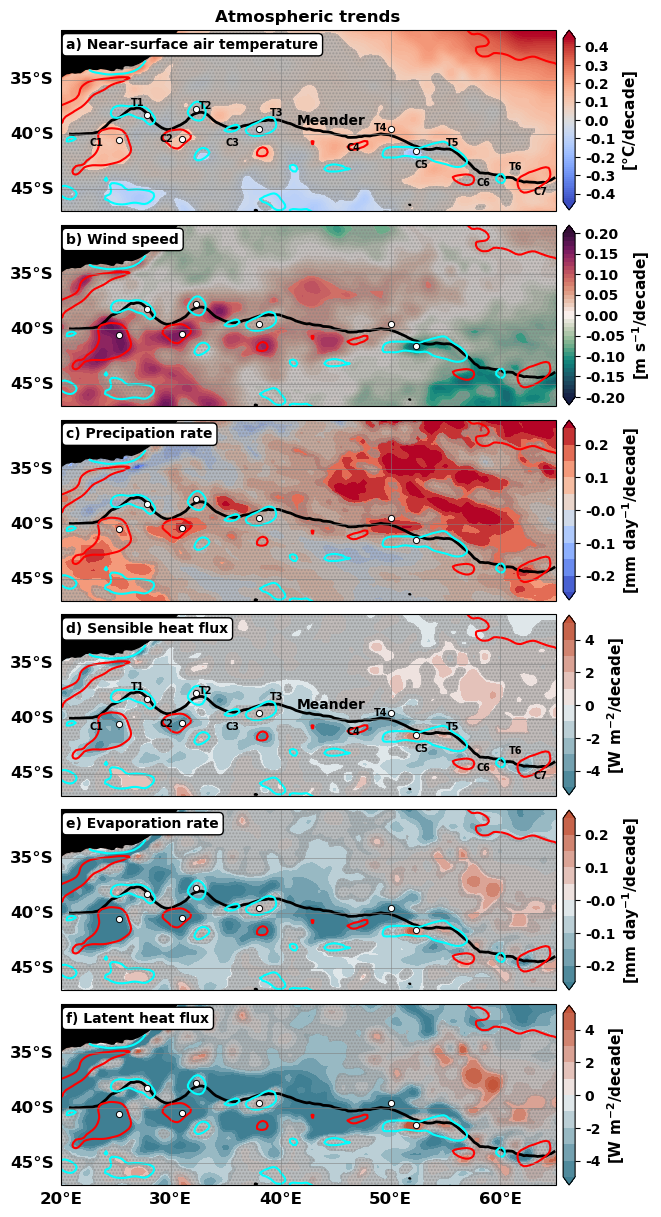

In [14]:
fig = plt.figure(figsize = (12,15))
grd = GridSpec(101,100)
extent = [19.99, 65.01, -47, -30.5]
props = dict(boxstyle='round', facecolor='w', alpha=1)
outline = mpe.withStroke(linewidth=2, foreground='w')

####################### FIGURE 
ax = [fig.add_subplot(grd[:16,:], projection=ccrs.PlateCarree()),
      fig.add_subplot(grd[17:33,:], projection=ccrs.PlateCarree()),
      fig.add_subplot(grd[34:50,:], projection=ccrs.PlateCarree()),
      fig.add_subplot(grd[51:67,:], projection=ccrs.PlateCarree()),
      fig.add_subplot(grd[68:84,:], projection=ccrs.PlateCarree()),
      fig.add_subplot(grd[85:101,:], projection=ccrs.PlateCarree())]

htch = ['.....']
####################### FIGURE 1
cf1 = ax[0].contourf(lon, lat, slope_decade_Ta, np.arange(-.4,.41,.01), cmap = 'coolwarm', extend='both')
hatch1 = ax[0].contourf(lon, lat, p_value_Ta, [0.05,1], cmap='Greys', hatches=htch, alpha=.5) 
####################### FIGURE 2
cf2 = ax[1].contourf(lon, lat, slope_decade_wind, np.arange(-.2,.21,.01), cmap = cm.curl, extend='both')
hatch2 = ax[1].contourf(lon, lat, p_value_wind, [0.05,1], cmap='Greys',alpha=.5, hatches=htch) 
####################### FIGURE 3
cf3 = ax[2].contourf(lon, lat, slope_decade_precipitation, np.arange(-.25,.3,.05), cmap = 'coolwarm', extend='both')
hatch3 = ax[2].contourf(lon, lat, p_value_precipitation, [0.05,1], cmap='Greys',alpha=.5, hatches=htch) 
####################### FIGURE 4
cf4 = ax[3].contourf(lon, lat, slope_decade_sshf, np.arange(-5,6,1), cmap = sns.diverging_palette(220, 20, as_cmap=True), extend='both')
hatch4 = ax[3].contourf(lon, lat, p_value_sshf, [0.05,1], cmap='Greys',alpha=.5, hatches=htch) 
####################### FIGURE 5
cf5 = ax[4].contourf(lon, lat, slope_decade_evaporation, np.arange(-.25,.3,.05), cmap = sns.diverging_palette(220, 20, as_cmap=True), extend='both')
hatch5 = ax[4].contourf(lon, lat, p_value_evaporation, [0.05,1], cmap='Greys',alpha=.5, hatches=htch) 
####################### FIGURE 6
cf6 = ax[5].contourf(lon, lat, slope_decade_slhf, np.arange(-5,6,1), cmap = sns.diverging_palette(220, 20, as_cmap=True), extend='both')
hatch6 = ax[5].contourf(lon, lat, p_value_slhf, [0.05,1], cmap='Greys',alpha=.5, hatches=htch) 

cf, cbar_ = [cf1, cf2, cf3, cf4, cf5, cf6], []
cf_hatch  = [hatch1, hatch2, hatch3, hatch4, hatch5, hatch6]
txt = ['a) Near-surface air temperature', 'b) Wind speed', 'c) Precipation rate', 'd) Sensible heat flux', 'e) Evaporation rate', 'f) Latent heat flux']
for i in range(len(ax)):
    line = ax[i].plot(lon_front, lat_front_mean, color = 'k', linewidth = 2)
    cr_SST = ax[i].contour(SST_lon, SST_lat, SST_trend, [-.1,.3], colors = ['cyan', 'red'], linestyles = 'solid')
    handles_SST, labels_SST = cr_SST.legend_elements()
    ax[i].annotate(text=txt[i], color='k', xy=(20.5,-32.2), xycoords='data', bbox=props, fontsize = 10, zorder = 300)  

    cf_hatch[i].collections[0].set_edgecolor('grey')
    cf_hatch[i].collections[0].set_linewidth(0)   
    ### Some annotation
    ft = 7
    if i == 0 or i == 3:
        ax[i].annotate(text='Meander', color='k', xy=(41.5,-39.1), xycoords='data', fontsize = 10, zorder = 300, fontweight = 'bold')
        ax[i].annotate(text='C1', color='k', xy=(22.6,-41), xycoords='data', fontsize = ft, zorder = 300)
        ax[i].annotate(text='T1', color='k', xy=(26.4,-37.35), xycoords='data', fontsize = ft, zorder = 300)
        ax[i].annotate(text='C2', color='k', xy=(29,-40.7), xycoords='data', fontsize = ft, zorder = 300)
        ax[i].annotate(text='T2', color='k', xy=(32.6,-37.7), xycoords='data', fontsize = ft, zorder = 300)
        ax[i].annotate(text='C3', color='k', xy=(35,-41), xycoords='data', fontsize = ft, zorder = 300)
        ax[i].annotate(text='T3', color='k', xy=(39,-38.3), xycoords='data', fontsize = ft, zorder = 300)
        ax[i].annotate(text='C4', color='k', xy=(46,-41.5), xycoords='data', fontsize = ft, zorder = 300)
        ax[i].annotate(text='T4', color='k', xy=(48.5,-39.7), xycoords='data', fontsize = ft, zorder = 300)
        ax[i].annotate(text='C5', color='k', xy=(52.2,-43), xycoords='data', fontsize = ft, zorder = 300)
        ax[i].annotate(text='T5', color='k', xy=(55,-41), xycoords='data', fontsize = ft, zorder = 300)
        ax[i].annotate(text='C6', color='k', xy=(57.8,-44.7), xycoords='data', fontsize = ft, zorder = 300)
        ax[i].annotate(text='T6', color='k', xy=(60.8,-43.2), xycoords='data', fontsize = ft, zorder = 300)
        ax[i].annotate(text='C7', color='k', xy=(63,-45.5), xycoords='data', fontsize = ft, zorder = 300)
    
    ## Scatter
    ax[i].scatter(lon_crest_1, lat_crest_1, s = 20, color = 'w', edgecolor = 'k', zorder = 50, linewidth=.7)
    ax[i].scatter(lon_crest_2, lat_crest_2, s = 20, color = 'w', edgecolor = 'k', zorder = 50, linewidth=.7)
    ax[i].scatter(lon_crest_4, lat_crest_4, s = 20, color = 'w', edgecolor = 'k', zorder = 50, linewidth=.7)
    # ax[i].scatter(lon_crest_7, lat_crest_7, s = 20, color = 'w', edgecolor = 'k', zorder = 50, linewidth=.7)
    ax[i].scatter(lon_trough_1, lat_trough_1, s = 20, color = 'w', edgecolor = 'k', zorder = 50, linewidth=.7)
    ax[i].scatter(lon_trough_2, lat_trough_2, s = 20, color = 'w', edgecolor = 'k', zorder = 50, linewidth=.7)
    ax[i].scatter(lon_trough_3, lat_trough_3, s = 20, color = 'w', edgecolor = 'k', zorder = 50, linewidth=.7)
    ax[i].scatter(lon_trough_4, lat_trough_4, s = 20, color = 'w', edgecolor = 'k', zorder = 50, linewidth=.7)
    
    ## Grid
    ax[i].set_extent(extent, ccrs.PlateCarree())
    ax[i].add_feature(cartopy.feature.COASTLINE)
    ax[i].add_feature(cartopy.feature.LAND, facecolor='k', zorder=10)
    gl = ax[i].gridlines(draw_labels = False, crs=ccrs.PlateCarree(), linewidth=0.4, color='grey')
    gl.left_labels = True
    gl.ylabel_style = {'size': 12}
    gl.ylocator = mticker.FixedLocator(np.arange(-60, -30, 5))
    gl.xlocator = mticker.FixedLocator(np.arange(10, 80, 10))

    # Colorbar
    # bar = plt.axes([0.8, 0.698-i*.17-i*.023, 0.01, 0.18])
    bar = plt.axes([0.725, 0.76-i*.12-i*.01, 0.01, 0.12])
    cbar = plt.colorbar(cf[i], cax = bar)  
    cbar.ax.tick_params(labelsize=10) 
    cbar_.append(cbar)
    if i == 0:
        # gl.top_labels = True
        cbar.ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.1f'))
        cbar_[i].set_label(r'[$\degree$C/decade]', fontsize = 11)
    if i == 1:
        cbar.ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.2f'))
        cbar_[i].set_label(r'[m s$^{-1}$/decade]', fontsize = 11)
    if i == 2 or i == 4:
        cbar.ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.1f'))
        # cbar_[i].set_label(r'[kg m$^{-2}$ day$^{-1}$/decade]', fontsize = 11)
        cbar_[i].set_label(r'[mm day$^{-1}$/decade]', fontsize = 11)
    if i == 3 or i == 5:
        cbar.ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.0f'))
        cbar_[i].set_label(r'[W m$^{-2}$/decade]', fontsize = 11)
gl.bottom_labels = True
ax[0].set_title('Atmospheric trends', fontsize = 12)

# ax[0].legend(handles_SST, 
#              [r'SST trend: -0.1$\degree$C decade$^{-1}$', 'SST trend: +0.3$\degree$C decade$^{-1}$'],
#              loc = 'upper right', fontsize = 7, facecolor = 'lightgrey', shadow=True)

plt.savefig(path_fig + 'Fig3.jpg', dpi =300, bbox_inches = 'tight')

## older versions

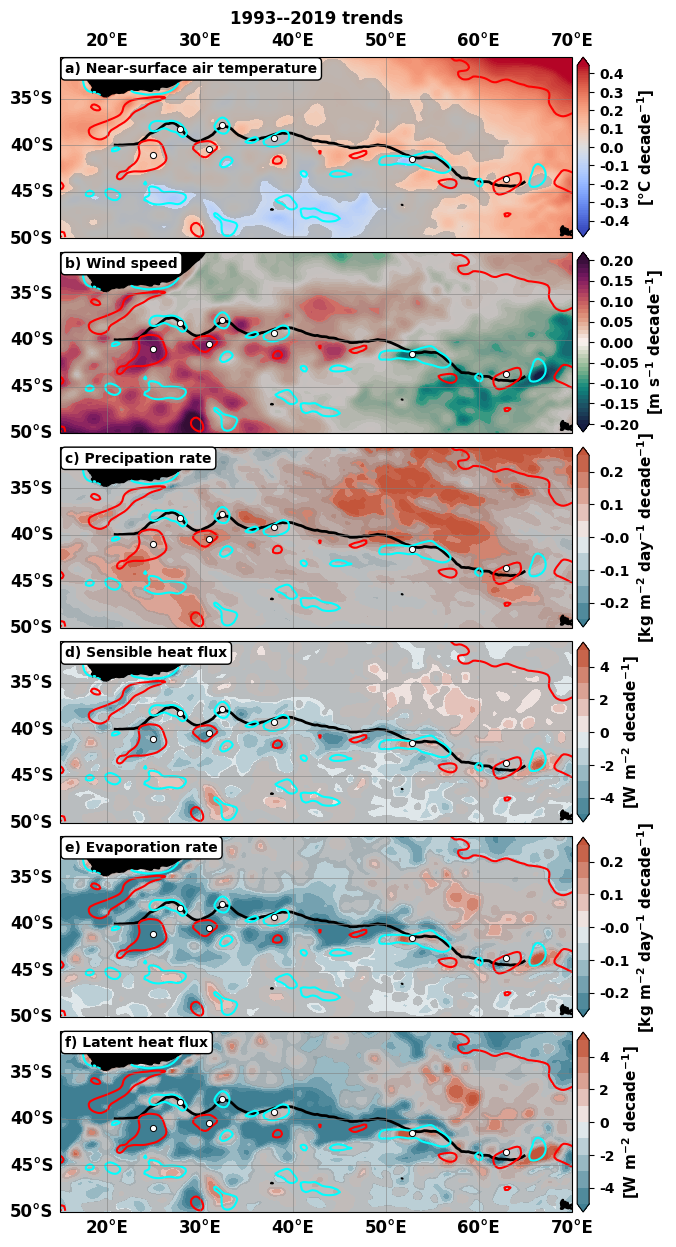

In [40]:
fig = plt.figure(figsize = (12,15))
grd = GridSpec(101,100)
extent = [19.99, 65.01, -49.9, -30.5]
props = dict(boxstyle='round', facecolor='w', alpha=1)
outline = mpe.withStroke(linewidth=2, foreground='w')

####################### FIGURE 
ax = [fig.add_subplot(grd[:16,:], projection=ccrs.PlateCarree()),
      fig.add_subplot(grd[17:33,:], projection=ccrs.PlateCarree()),
      fig.add_subplot(grd[34:50,:], projection=ccrs.PlateCarree()),
      fig.add_subplot(grd[51:67,:], projection=ccrs.PlateCarree()),
      fig.add_subplot(grd[68:84,:], projection=ccrs.PlateCarree()),
      fig.add_subplot(grd[85:101,:], projection=ccrs.PlateCarree())]

####################### FIGURE 1
cf1 = ax[0].contourf(lon, lat, slope_decade_Ta, np.arange(-.4,.41,.01), cmap = 'coolwarm', extend='both')
ax[0].contourf(lon, lat, p_value_Ta, [0.05,1], cmap='Greys',alpha=.5) 
####################### FIGURE 2
cf2 = ax[1].contourf(lon, lat, slope_decade_wind, np.arange(-.2,.21,.01), cmap = cm.curl, extend='both')
ax[1].contourf(lon, lat, p_value_wind, [0.05,1], cmap='Greys',alpha=.5) 
####################### FIGURE 3
cf3 = ax[2].contourf(lon, lat, slope_decade_precipitation, np.arange(-.25,.3,.05), cmap = sns.diverging_palette(220, 20, as_cmap=True), extend='both')
ax[2].contourf(lon, lat, p_value_precipitation, [0.05,1], cmap='Greys',alpha=.5) 
####################### FIGURE 4
cf4 = ax[3].contourf(lon, lat, slope_decade_sshf, np.arange(-5,6,1), cmap = sns.diverging_palette(220, 20, as_cmap=True), extend='both')
ax[3].contourf(lon, lat, p_value_sshf, [0.05,1], cmap='Greys',alpha=.5) 
####################### FIGURE 5
cf5 = ax[4].contourf(lon, lat, slope_decade_evaporation, np.arange(-.25,.3,.05), cmap = sns.diverging_palette(220, 20, as_cmap=True), extend='both')
ax[4].contourf(lon, lat, p_value_evaporation, [0.05,1], cmap='Greys',alpha=.5) 
####################### FIGURE 6
cf6 = ax[5].contourf(lon, lat, slope_decade_slhf, np.arange(-5,6,1), cmap = sns.diverging_palette(220, 20, as_cmap=True), extend='both')
ax[5].contourf(lon, lat, p_value_slhf, [0.05,1], cmap='Greys',alpha=.5) 

cf, cbar_ = [cf1, cf2, cf3, cf4, cf5, cf6], []
txt = ['a) Near-surface air temperature', 'b) Wind speed', 'c) Precipation rate', 'd) Sensible heat flux', 'e) Evaporation rate', 'f) Latent heat flux']
for i in range(len(ax)):
    line = ax[i].plot(lon_front, lat_front_mean, color = 'k', linewidth = 2)
    cr_SST = ax[i].contour(SST_lon, SST_lat, SST_trend, [-.1,.3], colors = ['cyan', 'red'], linestyles = 'solid')
    handles_SST, labels_SST = cr_SST.legend_elements()
    ax[i].annotate(text=txt[i], color='k', xy=(15.5,-32.2), xycoords='data', bbox=props, fontsize = 10, zorder = 300)  

    ## Scatter
    ax[i].scatter(lon_crest_1, lat_crest_1, s = 20, color = 'w', edgecolor = 'k', zorder = 50, linewidth=.7)
    ax[i].scatter(lon_crest_2, lat_crest_2, s = 20, color = 'w', edgecolor = 'k', zorder = 50, linewidth=.7)
    ax[i].scatter(lon_crest_4, lat_crest_4, s = 20, color = 'w', edgecolor = 'k', zorder = 50, linewidth=.7)
    ax[i].scatter(lon_crest_7, lat_crest_7, s = 20, color = 'w', edgecolor = 'k', zorder = 50, linewidth=.7)
    ax[i].scatter(lon_trough_1, lat_trough_1, s = 20, color = 'w', edgecolor = 'k', zorder = 50, linewidth=.7)
    ax[i].scatter(lon_trough_2, lat_trough_2, s = 20, color = 'w', edgecolor = 'k', zorder = 50, linewidth=.7)
    ax[i].scatter(lon_trough_3, lat_trough_3, s = 20, color = 'w', edgecolor = 'k', zorder = 50, linewidth=.7)
    
    ## Grid
    ax[i].set_extent(extent, ccrs.PlateCarree())
    ax[i].add_feature(cartopy.feature.COASTLINE)
    ax[i].add_feature(cartopy.feature.LAND, facecolor='k', zorder=10)
    gl = ax[i].gridlines(draw_labels = False, crs=ccrs.PlateCarree(), linewidth=0.4, color='grey')
    gl.left_labels = True
    gl.ylabel_style = {'size': 12}
    gl.ylocator = mticker.FixedLocator(np.arange(-60, -30, 5))
    gl.xlocator = mticker.FixedLocator(np.arange(10, 80, 10))

    # Colorbar
    # bar = plt.axes([0.8, 0.698-i*.17-i*.023, 0.01, 0.18])
    bar = plt.axes([0.73, 0.76-i*.12-i*.01, 0.01, 0.12])
    cbar = plt.colorbar(cf[i], cax = bar)  
    cbar.ax.tick_params(labelsize=10) 
    cbar_.append(cbar)
    if i == 0:
        gl.top_labels = True
        cbar.ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.1f'))
        cbar_[i].set_label(r'[$\degree$C decade$^{-1}$]', fontsize = 11)
    if i == 1:
        cbar.ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.2f'))
        cbar_[i].set_label(r'[m s$^{-1}$ decade$^{-1}$]', fontsize = 11)
    if i == 2 or i == 4:
        cbar.ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.1f'))
        cbar_[i].set_label(r'[kg m$^{-2}$ day$^{-1}$ decade$^{-1}$]', fontsize = 11)
    if i == 3 or i == 5:
        cbar.ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.0f'))
        cbar_[i].set_label(r'[W m$^{-2}$ decade$^{-1}$]', fontsize = 11)
gl.bottom_labels = True
ax[0].set_title('1993--2019 trends', fontsize = 12)

# ax[0].legend(handles_SST, 
#              [r'SST trend: -0.1$\degree$C decade$^{-1}$', 'SST trend: +0.3$\degree$C decade$^{-1}$'],
#              loc = 'upper right', fontsize = 7, facecolor = 'lightgrey', shadow=True)

# plt.savefig(path_fig + 'Fig5_v2.jpg', dpi =300, bbox_inches = 'tight')